In [2]:
if (!require("pacman")) install.packages("pacman")
pacman::p_load(tidyverse, ggplot2, dplyr, lubridate, fixest)

# HCRIS data 
final.hcris.data <- read_csv('../data/output/HCRIS_final.csv')

# State crosswalk 
state.crosswalk <- tibble(
  state = c("AL","AK","AZ","AR","CA","CO","CT","DE","FL","GA",
            "HI","ID","IL","IN","IA","KS","KY","LA","ME","MD",
            "MA","MI","MN","MS","MO","MT","NE","NV","NH","NJ",
            "NM","NY","NC","ND","OH","OK","OR","PA","RI","SC",
            "SD","TN","TX","UT","VT","VA","WA","WV","WI","WY","DC"),
  State = c("Alabama","Alaska","Arizona","Arkansas","California","Colorado",
            "Connecticut","Delaware","Florida","Georgia","Hawaii","Idaho",
            "Illinois","Indiana","Iowa","Kansas","Kentucky","Louisiana",
            "Maine","Maryland","Massachusetts","Michigan","Minnesota",
            "Mississippi","Missouri","Montana","Nebraska","Nevada",
            "New Hampshire","New Jersey","New Mexico","New York",
            "North Carolina","North Dakota","Ohio","Oklahoma","Oregon",
            "Pennsylvania","Rhode Island","South Carolina","South Dakota",
            "Tennessee","Texas","Utah","Vermont","Virginia","Washington",
            "West Virginia","Wisconsin","Wyoming","District of Columbia")
)

# KFF data 
kff.dat <- read_csv('kff_data.csv', skip=2)
kff.final <- kff.dat %>%
  rename(State = Location,
         Expansion.Status = `Status of Medicaid Expansion Decision`,
         date_adopted = `Expansion Implementation Date`) %>%
  filter(State %in% state.crosswalk$State) %>%
  mutate(expanded = (Expansion.Status == "Adopted"),
         date_adopted = mdy(date_adopted)) %>%
  select(State, expanded, date_adopted)

# Merge 
final.data <- final.hcris.data %>%
  left_join(state.crosswalk, by="state") %>%
  left_join(kff.final, by="State") %>%
  mutate(expand_year = year(date_adopted),
         expand = (year >= expand_year & !is.na(expand_year))) %>%
  rename(expand_ever = expanded) %>%
  mutate(uncomp_care_final = case_when(
    !is.na(uncomp_care) ~ uncomp_care,
    TRUE ~ tot_discounts + replace_na(bad_debt, 0)
  )) %>%
  filter(uncomp_care_final > 0 | is.na(expand_ever)) %>%        
  filter(is.na(expand_year) | expand_year == 2014) %>%          
  mutate(post = (year >= 2014),
         treat = as.integer(post) + as.integer(expand_ever))

Loading required package: pacman

Rows: 133679 Columns: 51
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr   (9): provider_number, data_source, street, city, state, zip, county, n...
dbl  (38): beds, tot_charges, net_pat_rev, tot_discounts, tot_operating_exp,...
date  (4): fy_start, fy_end, date_processed, date_created

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Warning message:
“One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat)”
Rows: 71 Columns: 6
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (6): Location, Status of Medicaid Expansion Decision, Expansion Implemen...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to qu

In [4]:
# Question 1: Mean uncompensated care by year (in millions) 
final.data <- final.hcris.data %>%
  left_join(state.crosswalk, by="state") %>%
  left_join(kff.final, by="State") %>%
  mutate(expand_year = year(date_adopted),
         expand = (year >= expand_year & !is.na(expand_year))) %>%
  rename(expand_ever = expanded) %>%
  mutate(uncomp_care_final = bad_debt + tot_uncomp_care_charges - tot_uncomp_care_partial_pmts) %>%
  filter(uncomp_care_final > 0 | is.na(expand_ever)) %>%
  filter(is.na(expand_year) | expand_year == 2014) %>%
  mutate(post = (year >= 2014),
         treat = as.integer(post) + as.integer(expand_ever))

q1.table <- final.data %>%
  ungroup() %>%
  filter(year >= 2011, year <= 2018) %>%
  group_by(year) %>%
  summarize(
    mean_uncomp_care = mean(uncomp_care_final, na.rm=TRUE) / 1000000,
    n_hospitals = n_distinct(provider_number)
  ) %>%
  ungroup()

knitr::kable(q1.table,
             col.names = c("Year", "Mean Uncompensated Care (Millions)", "Hospitals"),
             digits = 2,
             caption = "Mean Hospital Uncompensated Care by Year (2011-2018)")

#Interpretation: Uncompensated care has stayed relatively constant. 



Table: Mean Hospital Uncompensated Care by Year (2011-2018)

| Year| Mean Uncompensated Care (Millions)| Hospitals|
|----:|----------------------------------:|---------:|
| 2011|                              37.47|      1826|
| 2012|                              40.50|      2002|
| 2013|                              42.96|      2059|
| 2014|                              38.53|      2020|
| 2015|                              34.34|      2052|
| 2016|                              39.67|      2078|
| 2017|                              44.14|      1892|
| 2018|                              42.40|      1470|

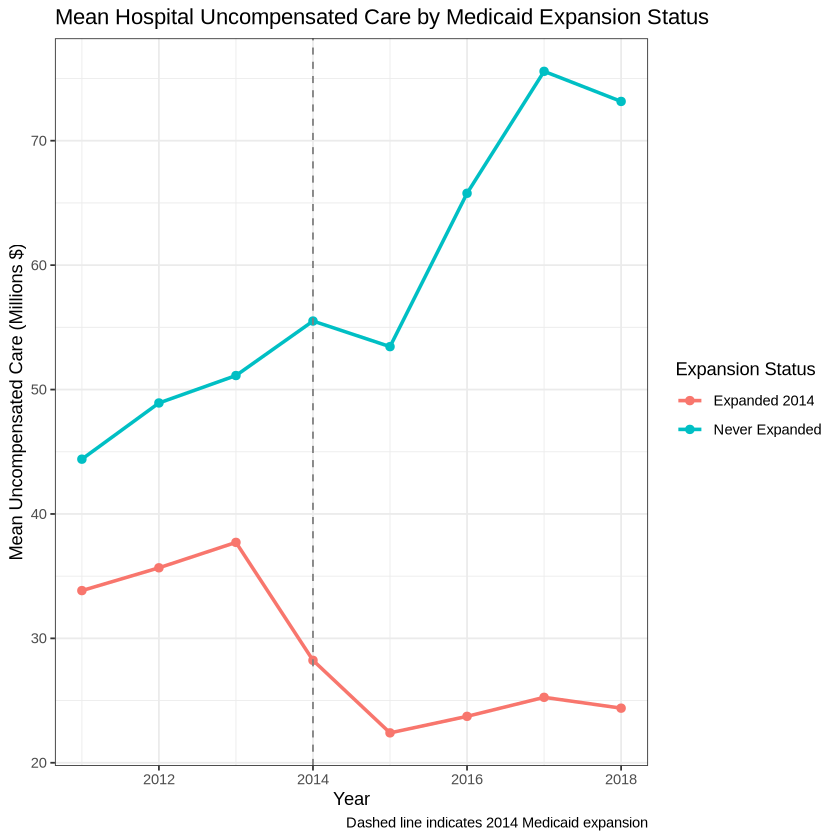

In [6]:
# Question 2: Plot mean uncompensated care by expansion status 
q2.data <- final.data %>%
  ungroup() %>%
  filter(year >= 2010, year <= 2018) %>%
  filter(!is.na(expand_ever)) %>%   # remove NA hospitals
  mutate(expand_group = ifelse(expand_ever == FALSE, "Never Expanded", "Expanded 2014")) %>%
  group_by(year, expand_group) %>%
  summarize(mean_uncomp_care = mean(uncomp_care_final, na.rm=TRUE) / 1000000, .groups="drop")

ggplot(q2.data, aes(x=year, y=mean_uncomp_care, color=expand_group)) +
  geom_line(size=1) +
  geom_point(size=2) +
  geom_vline(xintercept=2014, linetype="dashed", color="grey50") +
  labs(title = "Mean Hospital Uncompensated Care by Medicaid Expansion Status",
       x = "Year",
       y = "Mean Uncompensated Care (Millions $)",
       color = "Expansion Status",
       caption = "Dashed line indicates 2014 Medicaid expansion") +
  theme_bw()

#Interpretation: The graph does suggest a treatment effect as the expanded uncompensated care diverges from the 
#never expanded uncompensated care. 

In [11]:
# Question 3: 2x2 DD table (2012 pre, 2015 post) 
q3.data <- final.data %>%
  ungroup() %>%
  filter(year %in% c(2012, 2015)) %>%
  filter(!is.na(expand_ever)) %>%
  mutate(post = ifelse(year == 2015, "2015 (Post)", "2012 (Pre)"),
         group = ifelse(expand_ever == TRUE, "Expansion States", "Non-Expansion States")) %>%
  group_by(group, post) %>%
  summarize(mean_uncomp_care = mean(uncomp_care_final, na.rm=TRUE) / 1000000, .groups="drop") %>%
  pivot_wider(names_from = post, values_from = mean_uncomp_care) %>%
  rename(Group = group)

knitr::kable(q3.data,
             digits = 2,
             col.names = c("Group", "2012 (Pre)", "2015 (Post)"),
             caption = "2x2 DD Table of Mean Uncompensated Care (Millions $)")



Table: 2x2 DD Table of Mean Uncompensated Care (Millions $)

|Group                | 2012 (Pre)| 2015 (Post)|
|:--------------------|----------:|-----------:|
|Expansion States     |      35.67|       22.40|
|Non-Expansion States |      48.92|       53.45|

In [ ]:
#Question 4: Trend Discussion
#The non-expansion states saw uncompensated rates rise, likely due to general healthcare cost inflation and post-ACA coverage changes
#The expansion group decreased, consistent with Medicaid picking up previously uninsured patients.
#Medicaid expansion would be expected to reduce uncompensated care because newly insured patients who previously couldn't pay now 
#have coverage, reducing the burden on hospitals.

In [16]:
# Question 5: Standard DD regression 
q5.reg <- lm(uncomp_care_final/1000000 ~ expand + year + expand_ever,
             data = final.data %>% ungroup() %>% filter(year >= 2010, year <= 2018))

summary(q5.reg)


Call:
lm(formula = uncomp_care_final/1e+06 ~ expand + year + expand_ever, 
    data = final.data %>% ungroup() %>% filter(year >= 2010, 
        year <= 2018))

Residuals:
    Min      1Q  Median      3Q     Max 
 -68.74  -32.45  -18.68    3.04 2681.11 

Coefficients:
                  Estimate Std. Error t value Pr(>|t|)    
(Intercept)     -5963.8353   992.5794  -6.008 1.92e-09 ***
expandTRUE        -22.4771     2.8158  -7.983 1.54e-15 ***
year                2.9894     0.4927   6.067 1.34e-09 ***
expand_everTRUE   -15.0918     2.4060  -6.272 3.65e-10 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 97.77 on 14886 degrees of freedom
  (569 observations deleted due to missingness)
Multiple R-squared:  0.02439,	Adjusted R-squared:  0.02419 
F-statistic:   124 on 3 and 14886 DF,  p-value: < 2.2e-16


In [17]:
# Question 6: DD with hospital and year fixed effects 
q6.reg <- feols(uncomp_care_final/1000000 ~ expand | provider_number + year,
                cluster = ~state,
                data = final.data %>% ungroup() %>% filter(year >= 2010, year <= 2018))

summary(q6.reg)

#Interpretation: The point estimate decreases (more negative). 

NOTE: 568 observations removed because of NA values (LHS: 568).



OLS estimation, Dep. Var.: uncomp_care_final/1e+06
Observations: 14,891 
Fixed-effects: provider_number: 2,909,  year: 8
Standard-errors: Clustered (state) 
           Estimate Std. Error  t value   Pr(>|t|)    
expandTRUE -30.3498    5.60122 -5.41842 3.8498e-06 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 32.0     Adj. R2: 0.869625
             Within R2: 0.040775

In [18]:
# Question 7: DD with all states 
q7.data <- final.hcris.data %>%
  left_join(state.crosswalk, by="state") %>%
  left_join(kff.final, by="State") %>%
  mutate(expand_year = year(date_adopted),
         expand = (year >= expand_year & !is.na(expand_year))) %>%
  rename(expand_ever = expanded) %>%
  mutate(uncomp_care_final = bad_debt + tot_uncomp_care_charges - tot_uncomp_care_partial_pmts) %>%
  filter(uncomp_care_final > 0 | is.na(expand_ever)) %>%
  filter(year >= 2010, year <= 2018)

q7.reg <- feols(uncomp_care_final/1000000 ~ expand | provider_number + year,
                cluster = ~state,
                data = q7.data %>% ungroup())

summary(q7.reg)

#Interpretation: Now the data is capturing the effect for states that expanded in 2015, 2016, 2017, and 2018. These late expanders may have 
#expanded under different conditions, and their "post" period is much shorter within the 2010-2018 window. This dilutes the estimated effect.

NOTE: 568 observations removed because of NA values (LHS: 568).



OLS estimation, Dep. Var.: uncomp_care_final/1e+06
Observations: 19,975 
Fixed-effects: provider_number: 3,870,  year: 8
Standard-errors: Clustered (state) 
           Estimate Std. Error  t value   Pr(>|t|)    
expandTRUE -23.3524     4.5601 -5.12103 4.6885e-06 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 128.3     Adj. R2: 0.291357
              Within R2: 0.001868

NOTE: 569 observations removed because of NA values (LHS: 568, RHS: 569).



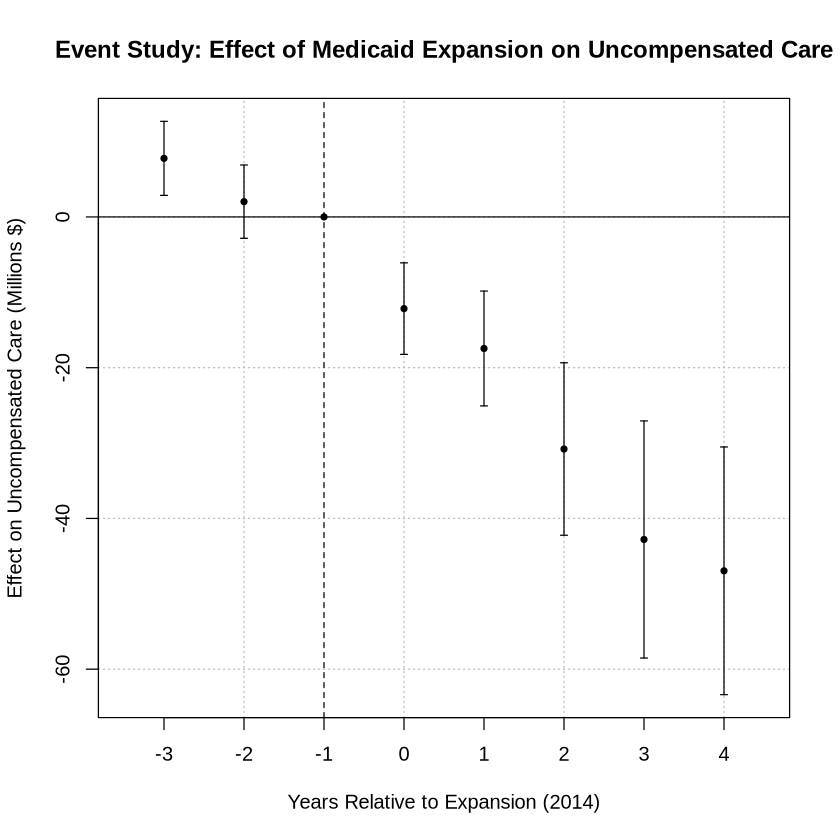

In [19]:
# Question 8: Event study - 2014 expanders and never-expanders only 
q8.data <- final.data %>%
  ungroup() %>%
  filter(year >= 2010, year <= 2018) %>%
  mutate(relative_year = ifelse(expand_ever == TRUE, year - 2014, -1),
         relative_year = factor(relative_year))

q8.reg <- feols(uncomp_care_final/1000000 ~ i(relative_year, expand_ever, ref="-1") |
                provider_number + year,
                cluster = ~state,
                data = q8.data)

iplot(q8.reg,
      main = "Event Study: Effect of Medicaid Expansion on Uncompensated Care",
      xlab = "Years Relative to Expansion (2014)",
      ylab = "Effect on Uncompensated Care (Millions $)")

NOTE: 569 observations removed because of NA values (LHS: 568, RHS: 569).



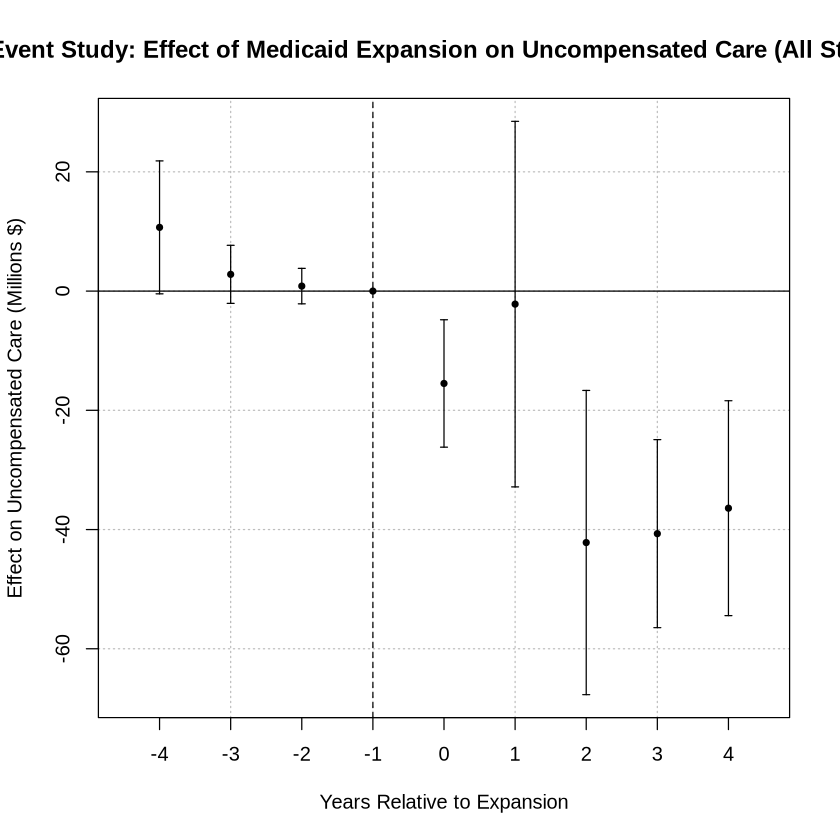

In [20]:
# Question 9: Event study - all states with binned event time 
q9.data <- q7.data %>%
  ungroup() %>%
  mutate(relative_year = ifelse(expand_ever == TRUE, year - expand_year, -1),
         relative_year = case_when(
           relative_year < -4 ~ -4,
           relative_year > 4  ~  4,
           TRUE               ~ relative_year
         ),
         relative_year = factor(relative_year))

q9.reg <- feols(uncomp_care_final/1000000 ~ i(relative_year, expand_ever, ref="-1") |
                provider_number + year,
                cluster = ~state,
                data = q9.data)

iplot(q9.reg,
      main = "Event Study: Effect of Medicaid Expansion on Uncompensated Care (All States)",
      xlab = "Years Relative to Expansion",
      ylab = "Effect on Uncompensated Care (Millions $)")

In [ ]:
#Question 10: Summary of Findings (Questions 5-9)
#Medicaid expansion is associated with a reduction in hospital uncompensated care. Q8 and Q9 provide support for parallel trends 
#as the pre-period coefficients are small and close to zero, though not perfectly flat. This suggests the parallel trends assumption is 
#approximately satisfied for 2014 expanders versus never-expanders. One limitation of the standard TWFE estimator in staggered designs is 
#that it uses already-treated units as controls for not-yet-treated units, 
#creating "forbidden comparisons" that can bias estimates toward zero. This suggests the true effect of Medicaid expansion on uncompensated 
#care is better captured by the cleaner 2014-versus-never-expander comparisons in Q6 and Q8.